In [6]:
# ── Parámetros a ajustar manualmente ──────────────────────────────────────────
P0_BINARY   = 0.05
P1_BINARY   = 150
P0_RRLYRAE  = 0.15
P1_RRLYRAE  = 1.0
P0_CEFEID   = 0.2
P1_CEFEID   = 150
P_NUM       = 10000
N_SAMPLE    = 3
RANDOM_SEED = 21
N_CANDIDATES = 5
PEAK_PROMINENCE=0.03
PEAK_DISTANCE = 50

ACTIVE_TYPES    = ["binary"]  # Subconjunto a procesar ("binary", "rrlyrae", "cefeid")
PLOT_ENTROPIES  = True  # Graficar periodograma de entropía, se recomienda solo con N_SAMPLE pequeños
PLOT_LIGHTCURVE = True  # Graficar curva de luz de la mejor solución

# ── Divisiones de grilla por tipo (t_parts=fases, u_parts=magnitudes) ─────────
GRID_PARTS = {
    "binary":  {"t_parts": 7, "u_parts": 7},
    "rrlyrae": {"t_parts": 7, "u_parts": 7},
    "cefeid":  {"t_parts": 10, "u_parts": 10},
}
# ──────────────────────────────────────────────────────────────────────────────

In [7]:
# Seleccionar algoritmo de mínima entropía
import least_entropy_candidates as le


Procesando: BINARY
  Muestra: 3 de 6 archivos disponibles


100%|██████████| 5953/5953 [00:09<00:00, 640.74it/s]


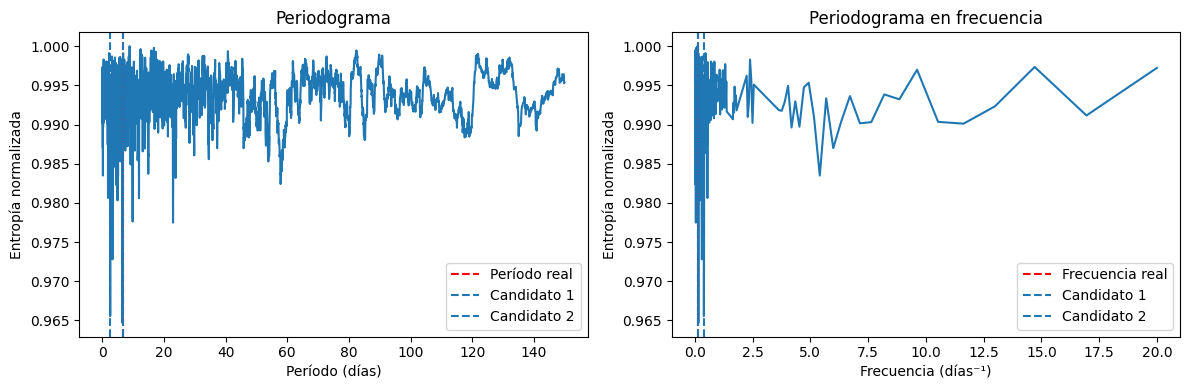

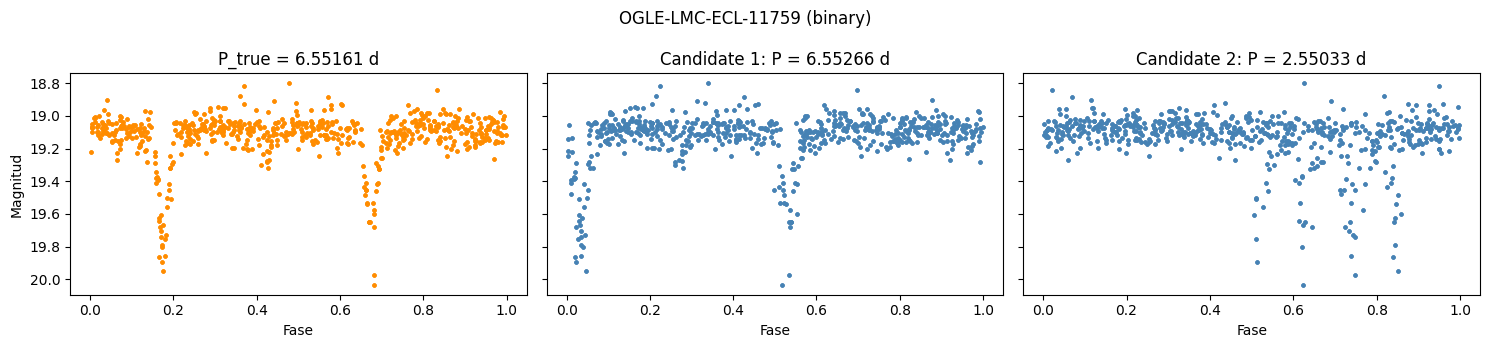

100%|██████████| 5941/5941 [00:09<00:00, 652.61it/s]]


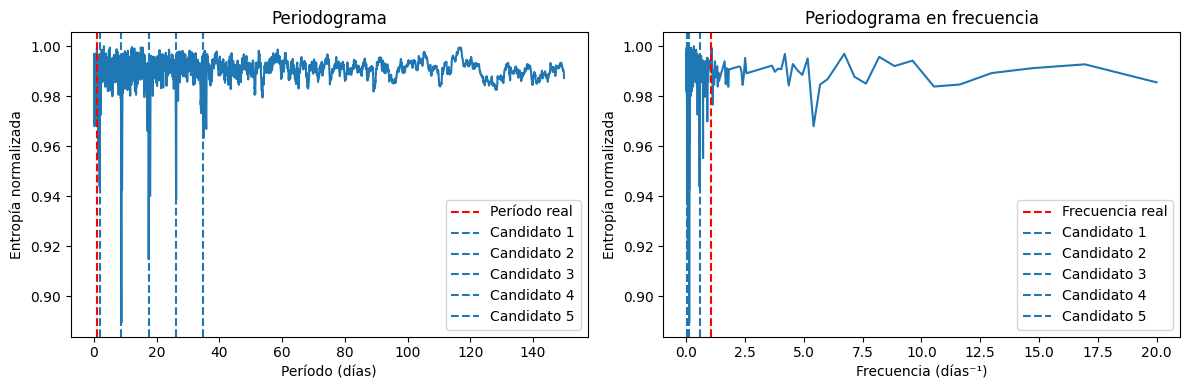

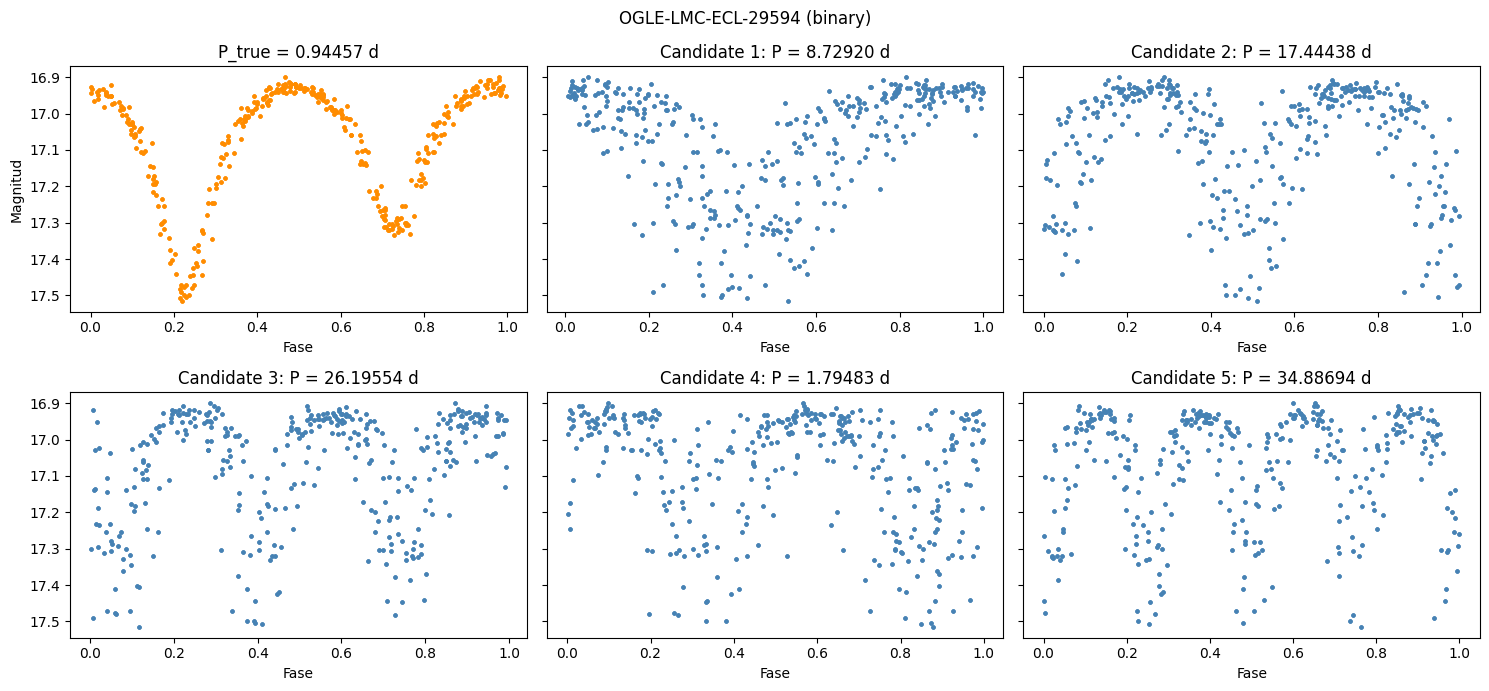

100%|██████████| 5904/5904 [00:09<00:00, 613.11it/s]]


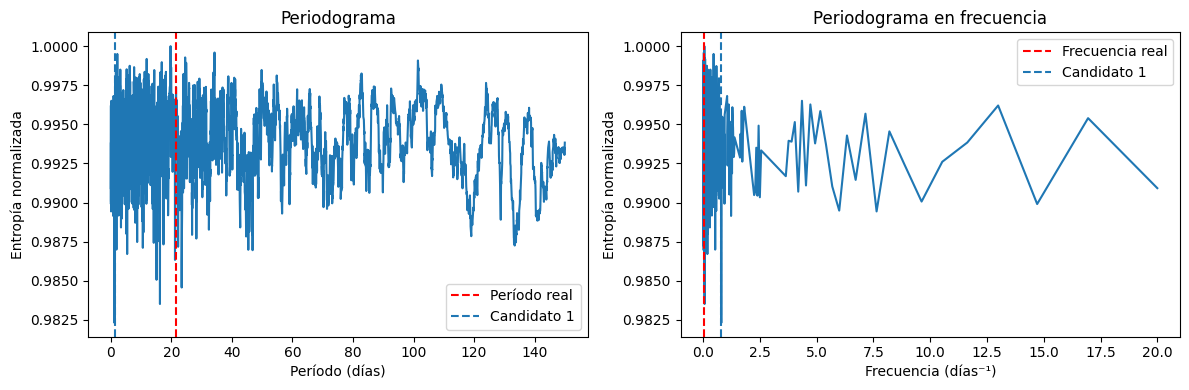

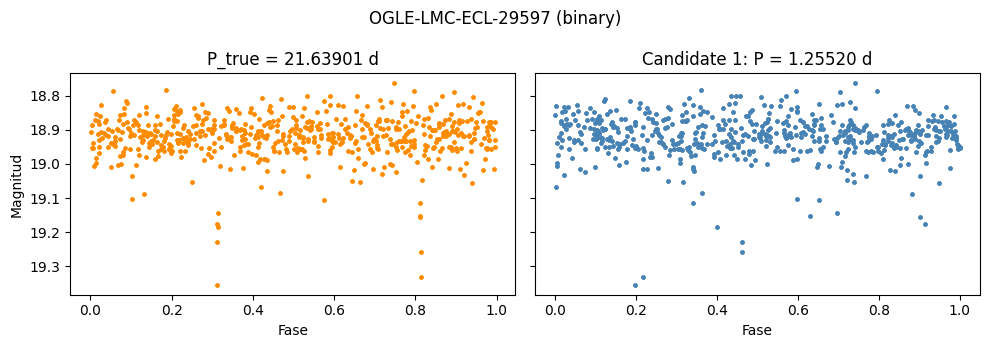

binary: 100%|██████████| 3/3 [00:32<00:00, 10.74s/it]


Listo. Resultados en df_results.
tipo
binary    0.666667
Name: recovery_rate, dtype: float64


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import testing_candidates as tst
import random
from datetime import datetime

COLLECTIONS = {
    "binary": {
        "dat_dir":  "ogle_collection/binaries_phot",
        "ref_file": "ogle_collection/binaries.txt",
        "p_col":    "P",
        "star_type": "binary",
        "p0": P0_BINARY,
        "p1": P1_BINARY,
    },
    "rrlyrae": {
        "dat_dir":  "ogle_collection/rrlyrae_phot",
        "ref_file": "ogle_collection/rrlyrae.txt",
        "p_col":    "P_1",
        "star_type": "rrlyrae",
        "p0": P0_RRLYRAE,
        "p1": P1_RRLYRAE,
    },
    "cefeid": {
        "dat_dir":  "ogle_collection/classical_cefeids_phot",
        "ref_file": "ogle_collection/classical_cefeids.txt",
        "p_col":    "P_1",
        "star_type": "cefeid",
        "p0": P0_CEFEID,
        "p1": P1_CEFEID,
    },
}


def load_reference(ref_file, p_col):
    df_ref = pd.read_csv(ref_file, skiprows=6, sep=r"\s+")
    ref = {}
    for _, row in df_ref.iterrows():
        ref[str(row["ID"])] = {
            "mag_I":  row["I"],
            "p_true": row[p_col],
        }
    return ref


def plot_lightcurve(
    data,
    candidate_periods,
    true_period,
    nombre,
    star_type,
    max_cols=3
):
    n_candidates = len(candidate_periods)
    n_panels = n_candidates + 1  # incluir p_true

    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5*n_cols, 3.5*n_rows),
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    mags = np.concatenate([data["u"], data["u"]])

    # ── panel 1: período real ───────────────────────────────
    phases_true = (data["t"] % true_period) / true_period
    phases_true = np.concatenate([phases_true, phases_true])

    axes[0].scatter(phases_true, mags, s=5, color="darkorange")
    axes[0].set_title(f"P_true = {true_period:.5f} d")
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Fase")
    axes[0].set_ylabel("Magnitud")

    # ── candidatos ─────────────────────────────────────────
    for i, p in enumerate(candidate_periods):

        phases = (data["t"] % p) / p
        phases = np.concatenate([phases, phases])

        axes[i+1].scatter(phases, mags, s=5, color="steelblue")

        axes[i+1].set_title(f"Candidate {i+1}: P = {p:.5f} d")
        axes[i+1].set_xlabel("Fase")

    # ocultar ejes sobrantes si hay
    for j in range(n_panels, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{nombre} ({star_type})")

    plt.tight_layout()
    plt.show()

# ── Validar ACTIVE_TYPES ──────────────────────────────────────────────────────
invalid = set(ACTIVE_TYPES) - set(COLLECTIONS)
if invalid:
    raise ValueError(f"Tipos no reconocidos en ACTIVE_TYPES: {invalid}")

# ── Bucle principal ───────────────────────────────────────────────────────────
all_results = []

for tipo, cfg in COLLECTIONS.items():
    if tipo not in ACTIVE_TYPES:
        continue

    print(f"\n{'='*50}")
    print(f"Procesando: {tipo.upper()}")
    print(f"{'='*50}")

    try:
        ref = load_reference(cfg["ref_file"], cfg["p_col"])
    except Exception as e:
        print(f"  [ERROR] No se pudo cargar la referencia {cfg['ref_file']}: {e}")
        continue

    archivos = [f for f in os.listdir(cfg["dat_dir"]) if f.endswith(".dat")]


    if N_SAMPLE is not None and N_SAMPLE < len(archivos):
        rng = random.Random(RANDOM_SEED)
        archivos = rng.sample(archivos, N_SAMPLE)
        print(f"  Muestra: {N_SAMPLE} de {len(archivos) + N_SAMPLE} archivos disponibles")
    else:
        print(f"  Procesando todos los archivos: {len(archivos)}")

    for archivo in tqdm(archivos, desc=tipo):
        nombre = archivo.split(".")[0]
        ruta   = os.path.join(cfg["dat_dir"], archivo)

        if nombre not in ref:
            print(f"  [WARN] {nombre} no encontrado en {cfg['ref_file']}, omitiendo.")
            continue

        p_true = ref[nombre]["p_true"]
        mag_I  = ref[nombre]["mag_I"]

        # Verificar que el período real esté dentro del rango de búsqueda
        if not (cfg["p0"] <= p_true <= cfg["p1"]):
            print(f"  [SKIP] {nombre} — p_true={p_true:.4f} fuera de [{cfg['p0']}, {cfg['p1']}]")
            continue

        try:
            data = pd.read_csv(ruta, sep=" ", lineterminator="\n", names=("t", "u", "inc_u"))
        except Exception as e:
            print(f"  [ERROR] {nombre} — no se pudo leer el .dat: {e}")
            continue

        try:
            candidate_periods, candidate_entropies, phases1, phases2 = le.find_best_period(
                data,
                p0=cfg["p0"], p1=cfg["p1"],
                p_num=P_NUM,
                star_type=cfg["star_type"],
                t_parts=GRID_PARTS[tipo]["t_parts"],
                u_parts=GRID_PARTS[tipo]["u_parts"],
                plot_entropies=PLOT_ENTROPIES,
                eps=0,
                plot_periods=False,
                p_teo=p_true,
                n_candidates=N_CANDIDATES,
                peak_prominence=PEAK_PROMINENCE,
                peak_distance=PEAK_DISTANCE
            )
        except Exception as e:
            print(f"  [ERROR] {nombre} — fallo en find_best_period: {e}")
            continue

        if PLOT_LIGHTCURVE:
            plot_lightcurve(
                data,
                candidate_periods,
                p_true,
                nombre,
                tipo
            )

        error = tst.period_error(candidate_periods, p_true)
        multiple = tst.which_multiple(candidate_periods, p_true)

        all_results.append({
            "id": nombre,
            "tipo": tipo,
            "mag_I": mag_I,
            "p_true": p_true,
            "p_candidates": candidate_periods.tolist(),
            "best_candidate": candidate_periods[0],
            "error": error,
            "multiple": multiple,
            "success": error < 0.05,
        })

df_results = pd.DataFrame(all_results)
print("\nListo. Resultados en df_results.")
print(df_results.groupby("tipo")["success"].mean().rename("recovery_rate"))

In [9]:
# Exportar resultados
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)

# ── Preparar dataframe para exportar ─────────────────────────────────────
df_export = df_results.copy()

# Convertir listas de candidatos a string (CSV-safe)
if "p_candidates" in df_export.columns:
    df_export["p_candidates"] = df_export["p_candidates"].apply(lambda x: ",".join(map(str, x)))

df_export.to_csv(f"resultados_masivos/resultados_{timestamp}.csv", index=False)

# ── Parámetros ───────────────────────────────────────────────────────────
params = {
    "timestamp":        timestamp,
    "P0_BINARY":        P0_BINARY,
    "P1_BINARY":        P1_BINARY,
    "P0_RRLYRAE":       P0_RRLYRAE,
    "P1_RRLYRAE":       P1_RRLYRAE,
    "P0_CEFEID":        P0_CEFEID,
    "P1_CEFEID":        P1_CEFEID,
    "P_NUM":            P_NUM,
    "N_SAMPLE":         N_SAMPLE,
    "RANDOM_SEED":      RANDOM_SEED,
    "ACTIVE_TYPES":     str(ACTIVE_TYPES),
    "PLOT_ENTROPIES":   PLOT_ENTROPIES,
    "PLOT_LIGHTCURVE":  PLOT_LIGHTCURVE,

    # nuevos parámetros candidatos
    "N_CANDIDATES":     N_CANDIDATES,
    "PEAK_PROMINENCE":  PEAK_PROMINENCE,
    "PEAK_DISTANCE":    PEAK_DISTANCE,
}

pd.DataFrame([params]).to_csv(
    f"resultados_masivos/params_{timestamp}.csv",
    index=False
)

print(f"Guardado en: resultados_masivos/resultados_{timestamp}.csv")
print(f"Parámetros en: resultados_masivos/params_{timestamp}.csv")

Guardado en: resultados_masivos/resultados_20260424_110245.csv
Parámetros en: resultados_masivos/params_20260424_110245.csv


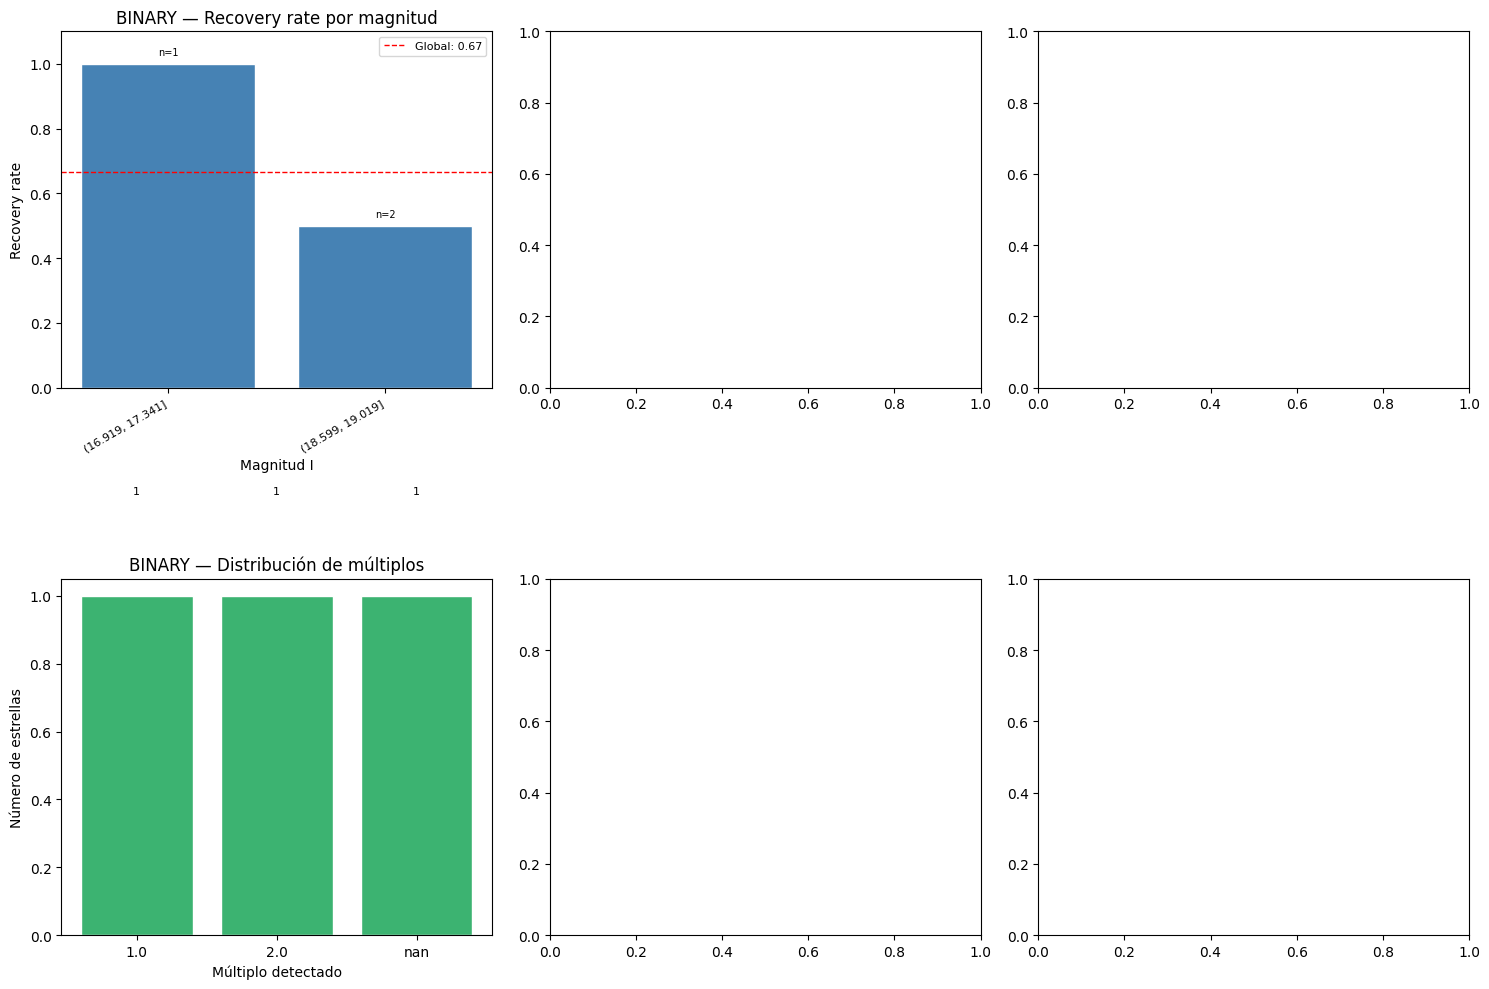

Gráficas guardadas en: resultados_masivos/recovery_bars_20260424_110245.png


In [10]:
# Graficar
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
tipos = ACTIVE_TYPES

for col, tipo in enumerate(tipos):

    df_tipo = df_results[df_results["tipo"] == tipo]

    if len(df_tipo) == 0:
        continue

    # ── Recovery rate por magnitud ─────────────────────────────
    ax_mag = axes[0, col]

    bins = pd.cut(df_tipo["mag_I"], bins=5)

    recovery = df_tipo.groupby(bins, observed=True)["success"].mean()
    counts   = df_tipo.groupby(bins, observed=True)["success"].count()

    x = range(len(recovery))

    bars = ax_mag.bar(
        x,
        recovery.values,
        color="steelblue",
        edgecolor="white"
    )

    ax_mag.set_xticks(x)
    ax_mag.set_xticklabels(
        [str(b) for b in recovery.index],
        rotation=30,
        ha="right",
        fontsize=8
    )

    ax_mag.set_ylim(0, 1.1)
    ax_mag.set_xlabel("Magnitud I")
    ax_mag.set_ylabel("Recovery rate")

    global_rr = df_tipo["success"].mean()

    ax_mag.set_title(f"{tipo.upper()} — Recovery rate por magnitud")

    ax_mag.axhline(
        global_rr,
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Global: {global_rr:.2f}"
    )

    ax_mag.legend(fontsize=8)

    for bar, n in zip(bars, counts.values):
        ax_mag.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=7
        )

    # ── Distribución de múltiplos ──────────────────────────────
    ax_mul = axes[1, col]

    mul_counts = df_tipo["multiple"].value_counts(dropna=False).sort_index()

    labels = [
        str(m) if m is not None else "Fallo"
        for m in mul_counts.index
    ]

    colors = [
        "salmon" if l == "Fallo" else "mediumseagreen"
        for l in labels
    ]

    ax_mul.bar(labels, mul_counts.values, color=colors, edgecolor="white")

    ax_mul.set_xlabel("Múltiplo detectado")
    ax_mul.set_ylabel("Número de estrellas")

    ax_mul.set_title(f"{tipo.upper()} — Distribución de múltiplos")

    for i, val in enumerate(mul_counts.values):
        ax_mul.text(i, val + 0.3, str(val), ha="center", fontsize=8)


plt.tight_layout()

plt.savefig(
    f"resultados_masivos/recovery_bars_{timestamp}.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Gráficas guardadas en: resultados_masivos/recovery_bars_{timestamp}.png")